# D3 — Evaluation + Ablation (Member 3)
### Part 2: Run the Gold Set Through Every Mode + the Weight-Grid Ablation

This notebook reuses two things instead of duplicating them:

- Member 1's `ask()` / `run_graphrag_executor()` / `MODE_PRESETS` from `graphrag_executor.ipynb`
- This project's own `gold_qa_set` + `score_faithfulness()` / `score_answer_relevance()` from
  `D3_evaluation_gold_set.ipynb`

Both get pulled in by executing the other notebook's code cells into this kernel's namespace
(see Section 1) rather than hand-copying functions, so changes either of you make upstream stay
in sync automatically.

**Prerequisite:** run `D3_evaluation_gold_set.ipynb` at least once first, so
`gold_set_for_review.csv` (optionally hand-reviewed) and `gold_qa_set.json` already exist on
disk in `notebook_cache/06_eval_ablation/`.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path("..").resolve()
CACHE_DIR = PROJECT_ROOT / "notebook_cache"
EVAL_ABLATION_CACHE = CACHE_DIR / "06_eval_ablation"
EVAL_ABLATION_CACHE.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Eval/ablation cache:", EVAL_ABLATION_CACHE)

Project root: C:\Users\97150\Documents\GitHub\CLPapersAIAgent
Eval/ablation cache: C:\Users\97150\Documents\GitHub\CLPapersAIAgent\notebook_cache\06_eval_ablation


## 1. Pull in `ask()` and the gold-set / judge functions

`run_notebook_into_namespace()` reads another notebook's code cells with `nbformat` and `exec`s
each one into *this* notebook's globals -- effectively treating the other notebook as a module,
without either notebook needing to be rewritten as a `.py` file. Output from the imported
notebook is captured/suppressed so it doesn't spam this one; only the confirmation prints below
are shown.

In [3]:
import nbformat
from IPython.utils.capture import capture_output


def run_notebook_into_namespace(notebook_path, target_globals, quiet=True):
    """Execute every code cell of another notebook into this kernel's namespace.

    This is how this notebook reuses Member 1's ask()/run_graphrag_executor() and this
    project's own gold-set + judge functions, without duplicating that logic by hand or
    turning either notebook into a separate .py module.
    """
    notebook_path = Path(notebook_path)
    if not notebook_path.exists():
        raise FileNotFoundError(
            f"{notebook_path} not found. It needs to live in the same notebooks/ folder "
            "as this notebook."
        )

    nb_in = nbformat.read(notebook_path, as_version=4)
    code_cells = [c for c in nb_in.cells if c.cell_type == "code"]

    if quiet:
        with capture_output():
            for cell in code_cells:
                exec(cell.source, target_globals)
    else:
        for cell in code_cells:
            exec(cell.source, target_globals)

    return len(code_cells)

In [4]:
n1 = run_notebook_into_namespace("graphrag_executor.ipynb", globals())
print(f"Loaded {n1} code cells from graphrag_executor.ipynb")
print("ask() available:", "ask" in globals(), "| MODE_PRESETS:", list(MODE_PRESETS.keys()))

n2 = run_notebook_into_namespace("D3_evaluation_gold_set.ipynb", globals())
print(f"Loaded {n2} code cells from D3_evaluation_gold_set.ipynb")
print("gold_qa_set questions:", len(gold_qa_set))
print("score_faithfulness available:", "score_faithfulness" in globals())
print("USE_LLM_JUDGE:", USE_LLM_JUDGE)

Loaded 41 code cells from graphrag_executor.ipynb
ask() available: True | MODE_PRESETS: ['vector_only', 'graph_guided', 'hybrid_graphrag']
Loaded 10 code cells from D3_evaluation_gold_set.ipynb
gold_qa_set questions: 12
score_faithfulness available: True
USE_LLM_JUDGE: False


## 2. Define the configs to sweep

Three named presets (Member 1's `MODE_PRESETS`) plus the five-point `WEIGHT_GRID` from the
"test multiple combinations" suggestion. The grid is built on top of the `hybrid_graphrag`
preset specifically because it's the only base whose `use_graph` flag stays `True` across the
whole sweep -- only the three score weights change row to row, never the structural on/off
switch. `EVIDENCE_BUDGET` is passed identically to *every* call below (presets and grid alike),
which is the "keep the evidence budget fixed" requirement -- it isolates the weights as the only
variable in the ablation.

In [5]:
EVIDENCE_BUDGET = 8  # fixed across every config in this sweep -- do not vary per-row

WEIGHT_GRID = [
    {"retrieval_weight": 1.0, "graph_weight": 0.0, "quality_weight": 0.0},
    {"retrieval_weight": 0.8, "graph_weight": 0.1, "quality_weight": 0.1},
    {"retrieval_weight": 0.7, "graph_weight": 0.2, "quality_weight": 0.1},
    {"retrieval_weight": 0.6, "graph_weight": 0.3, "quality_weight": 0.1},
    {"retrieval_weight": 0.5, "graph_weight": 0.4, "quality_weight": 0.1},
]

MODE_CONFIGS = [
    {"label": "vector_only", "mode": "vector_only", "weights": None},
    {"label": "graph_guided", "mode": "graph_guided", "weights": None},
    {"label": "hybrid_graphrag", "mode": "hybrid_graphrag", "weights": None},
]

ABLATION_CONFIGS = [
    {
        "label": f"grid_r{w['retrieval_weight']}_g{w['graph_weight']}_q{w['quality_weight']}",
        "mode": "hybrid_graphrag",   # base preset; only its weights get overridden below
        "weights": w,
    }
    for w in WEIGHT_GRID
]

ALL_CONFIGS = MODE_CONFIGS + ABLATION_CONFIGS

print(f"{len(ALL_CONFIGS)} configs x {len(gold_qa_set)} gold questions = "
      f"{len(ALL_CONFIGS) * len(gold_qa_set)} ask() calls "
      f"(~{2 * len(ALL_CONFIGS) * len(gold_qa_set)} judge calls if USE_LLM_JUDGE is True).")
display(pd.DataFrame(ALL_CONFIGS))

8 configs x 12 gold questions = 96 ask() calls (~192 judge calls if USE_LLM_JUDGE is True).


,label,mode,weights
0,vector_only,vector_only,None
1,graph_guided,graph_guided,None
2,hybrid_graphrag,hybrid_graphrag,None
3,grid_r1.0_g0.0_q0.0,hybrid_graphrag,"{'retrieval_weight': 1.0, 'graph_weight': 0.0, 'quality_weight': 0.0}"
4,grid_r0.8_g0.1_q0.1,hybrid_graphrag,"{'retrieval_weight': 0.8, 'graph_weight': 0.1, 'quality_weight': 0.1}"
5,grid_r0.7_g0.2_q0.1,hybrid_graphrag,"{'retrieval_weight': 0.7, 'graph_weight': 0.2, 'quality_weight': 0.1}"
6,grid_r0.6_g0.3_q0.1,hybrid_graphrag,"{'retrieval_weight': 0.6, 'graph_weight': 0.3, 'quality_weight': 0.1}"
7,grid_r0.5_g0.4_q0.1,hybrid_graphrag,"{'retrieval_weight': 0.5, 'graph_weight': 0.4, 'quality_weight': 0.1}"


## 3. Run every gold question through every config

For each run: pull the answer + final evidence out of the `ask()` response, score faithfulness
(answer vs. its own cited evidence) and answer relevance (answer vs. question), read citation
coverage and total latency straight out of `quality_checks`/`timing`, and compute precision/
recall of the cited papers against this question's `gold_relevant_paper_ids`. That last pair is
the more meaningful citation metric -- Member 1's `citation_coverage` is `len(citations) /
len(final_evidence)`, which is ~1.0 by construction since every surviving evidence item gets a
citation; gold precision/recall actually checks whether the *right* papers got cited.

This will take a few minutes if the LLM judge is active (one faithfulness + one relevance call
per run); it's fast if running on the heuristic fallback.

In [6]:
results = []

for q in tqdm(gold_qa_set, desc="gold questions"):
    gold_ids = set(q.get("gold_relevant_paper_ids", []))

    for cfg in ALL_CONFIGS:
        weights = cfg["weights"] or {}

        response = ask(
            question=q["question"],
            mode=cfg["mode"],
            top_k=5,
            seed_papers=3,
            expand_k=5,
            max_chunks_per_graph_paper=2,
            max_total_evidence_chunks=EVIDENCE_BUDGET,
            retrieval_weight=weights.get("retrieval_weight"),
            graph_weight=weights.get("graph_weight"),
            quality_weight=weights.get("quality_weight"),
            return_trace=True,
            include_candidate_evidence=False,
            save_trace=False,   # this is a sweep, not individual demo traces
        )

        answer = response.get("answer", "")
        final_evidence = response.get("final_evidence", [])
        evidence_snippets = [item.get("snippet", "") for item in final_evidence]
        cited_paper_ids = {c["paper_id"] for c in response.get("citations", [])}

        faith = score_faithfulness(q["question"], answer, evidence_snippets)
        rel = score_answer_relevance(q["question"], answer)

        if gold_ids:
            gold_recall = len(cited_paper_ids & gold_ids) / len(gold_ids)
            gold_precision = (
                len(cited_paper_ids & gold_ids) / len(cited_paper_ids) if cited_paper_ids else 0.0
            )
        else:
            gold_recall = None
            gold_precision = None

        base_weights = MODE_PRESETS[cfg["mode"]]
        results.append({
            "question_id": q["question_id"],
            "category": q["category"],
            "config": cfg["label"],
            "retrieval_weight": weights.get("retrieval_weight", base_weights["retrieval_weight"]),
            "graph_weight": weights.get("graph_weight", base_weights["graph_weight"]),
            "quality_weight": weights.get("quality_weight", base_weights["quality_weight"]),
            "faithfulness": faith["score"],
            "answer_relevance": rel["score"],
            "citation_coverage": response.get("quality_checks", {}).get("citation_coverage"),
            "gold_paper_precision": gold_precision,
            "gold_paper_recall": gold_recall,
            "total_ms": response.get("timing", {}).get("total_ms"),
        })

results_df = pd.DataFrame(results)
results_path = EVAL_ABLATION_CACHE / "ablation_results_long.csv"
results_df.to_csv(results_path, index=False)

print(f"Saved {len(results_df)} rows -> {results_path}")
display(results_df.head(10))

gold questions:   0%|          | 0/12 [00:00<?, ?it/s]

Saved 96 rows -> C:\Users\97150\Documents\GitHub\CLPapersAIAgent\notebook_cache\06_eval_ablation\ablation_results_long.csv


,question_id,category,config,retrieval_weight,graph_weight,quality_weight,faithfulness,answer_relevance,citation_coverage,gold_paper_precision,gold_paper_recall,total_ms
0,q002,pretraining,vector_only,1.0,0.0,0.0,3.59,1.82,1.0,0.400000,0.030769,109.95
1,q002,pretraining,graph_guided,0.5,0.4,0.1,2.67,1.29,1.0,0.400000,0.030769,239.49
2,q002,pretraining,hybrid_graphrag,0.8,0.1,0.1,2.92,1.82,1.0,0.500000,0.061538,244.01
3,q002,pretraining,grid_r1.0_g0.0_q0.0,1.0,0.0,0.0,2.92,1.82,1.0,0.500000,0.061538,203.47
4,q002,pretraining,grid_r0.8_g0.1_q0.1,0.8,0.1,0.1,2.92,1.82,1.0,0.500000,0.061538,241.33
5,q002,pretraining,grid_r0.7_g0.2_q0.1,0.7,0.2,0.1,2.92,1.82,1.0,0.500000,0.061538,202.18
6,q002,pretraining,grid_r0.6_g0.3_q0.1,0.6,0.3,0.1,3.20,1.34,1.0,0.571429,0.061538,235.24
7,q002,pretraining,grid_r0.5_g0.4_q0.1,0.5,0.4,0.1,2.67,1.29,1.0,0.400000,0.030769,178.84
8,q007,evaluation,vector_only,1.0,0.0,0.0,3.72,1.85,1.0,0.600000,0.076923,152.58
9,q007,evaluation,graph_guided,0.5,0.4,0.1,3.00,1.04,1.0,0.500000,0.076923,249.82


## 4. Aggregate into the comparison table

In [7]:
def p95(series):
    clean = series.dropna()
    return float(np.percentile(clean, 95)) if len(clean) else None

summary_df = results_df.groupby("config").agg(
    retrieval_weight=("retrieval_weight", "first"),
    graph_weight=("graph_weight", "first"),
    quality_weight=("quality_weight", "first"),
    mean_faithfulness=("faithfulness", "mean"),
    mean_answer_relevance=("answer_relevance", "mean"),
    mean_citation_coverage=("citation_coverage", "mean"),
    mean_gold_precision=("gold_paper_precision", "mean"),
    mean_gold_recall=("gold_paper_recall", "mean"),
    avg_latency_ms=("total_ms", "mean"),
    p95_latency_ms=("total_ms", p95),
).reset_index()

preset_order = ["vector_only", "graph_guided", "hybrid_graphrag"]


def sort_key(row):
    if row["config"] in preset_order:
        return (0, preset_order.index(row["config"]))
    return (1, row["graph_weight"])


summary_df["_sort"] = summary_df.apply(sort_key, axis=1)
summary_df = summary_df.sort_values("_sort").drop(columns="_sort").reset_index(drop=True)

summary_path = EVAL_ABLATION_CACHE / "ablation_summary.csv"
summary_df.to_csv(summary_path, index=False)

print(f"Saved summary -> {summary_path}")
display(summary_df)

Saved summary -> C:\Users\97150\Documents\GitHub\CLPapersAIAgent\notebook_cache\06_eval_ablation\ablation_summary.csv


,config,retrieval_weight,graph_weight,quality_weight,mean_faithfulness,mean_answer_relevance,mean_citation_coverage,mean_gold_precision,mean_gold_recall,avg_latency_ms,p95_latency_ms
0,vector_only,1.0,0.0,0.0,3.664167,1.6450,1.0,0.577778,0.132616,178.275833,229.7780
1,graph_guided,0.5,0.4,0.1,2.821667,1.0075,1.0,0.418056,0.161164,275.659167,334.9550
2,hybrid_graphrag,0.8,0.1,0.1,2.994167,1.6500,1.0,0.463095,0.180412,257.645833,317.4685
3,grid_r1.0_g0.0_q0.0,1.0,0.0,0.0,2.950000,1.6450,1.0,0.463095,0.180412,254.116667,342.2485
4,grid_r0.8_g0.1_q0.1,0.8,0.1,0.1,2.994167,1.6500,1.0,0.463095,0.180412,267.757500,330.5485
5,grid_r0.7_g0.2_q0.1,0.7,0.2,0.1,2.990000,1.6350,1.0,0.485317,0.183884,267.945833,349.1225
6,grid_r0.6_g0.3_q0.1,0.6,0.3,0.1,3.102500,1.3400,1.0,0.489484,0.181747,247.440000,292.8470
7,grid_r0.5_g0.4_q0.1,0.5,0.4,0.1,2.821667,1.0075,1.0,0.418056,0.161164,270.924167,332.2605


## 5. Plots

Left: how faithfulness, answer relevance, and gold-paper recall move as `graph_weight`
increases across the fixed-budget weight grid. Right: the latency cost of that same sweep.

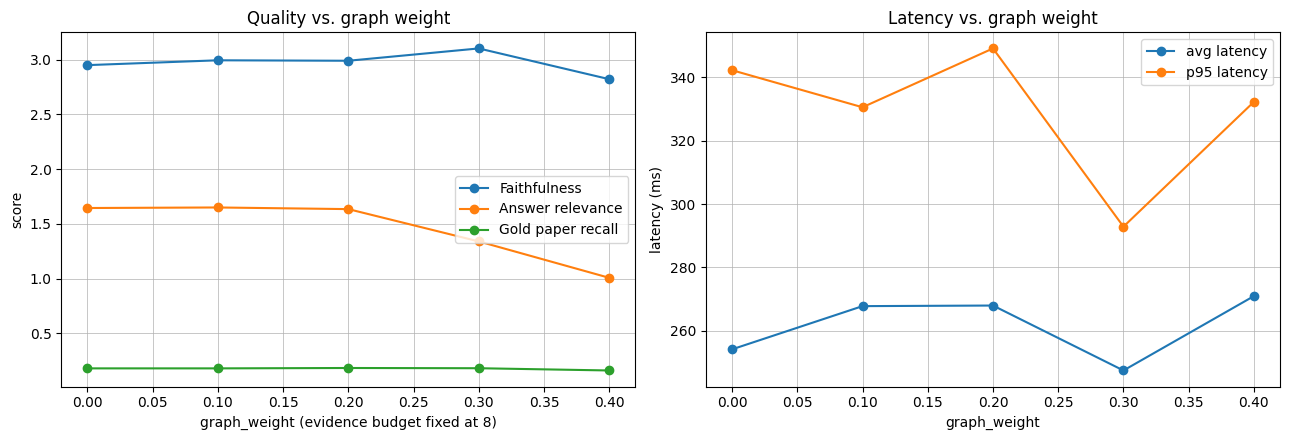

Saved plot -> C:\Users\97150\Documents\GitHub\CLPapersAIAgent\notebook_cache\06_eval_ablation\ablation_weight_sweep.png


In [8]:
grid_rows = summary_df[summary_df["config"].str.startswith("grid_")].sort_values("graph_weight")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(grid_rows["graph_weight"], grid_rows["mean_faithfulness"], marker="o", label="Faithfulness")
axes[0].plot(grid_rows["graph_weight"], grid_rows["mean_answer_relevance"], marker="o", label="Answer relevance")
axes[0].plot(grid_rows["graph_weight"], grid_rows["mean_gold_recall"], marker="o", label="Gold paper recall")
axes[0].set_xlabel(f"graph_weight (evidence budget fixed at {EVIDENCE_BUDGET})")
axes[0].set_ylabel("score")
axes[0].set_title("Quality vs. graph weight")
axes[0].legend()
axes[0].grid(True, linewidth=0.5)

axes[1].plot(grid_rows["graph_weight"], grid_rows["avg_latency_ms"], marker="o", label="avg latency")
axes[1].plot(grid_rows["graph_weight"], grid_rows["p95_latency_ms"], marker="o", label="p95 latency")
axes[1].set_xlabel("graph_weight")
axes[1].set_ylabel("latency (ms)")
axes[1].set_title("Latency vs. graph weight")
axes[1].legend()
axes[1].grid(True, linewidth=0.5)

plt.tight_layout()
sweep_plot_path = EVAL_ABLATION_CACHE / "ablation_weight_sweep.png"
plt.savefig(sweep_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved plot ->", sweep_plot_path)

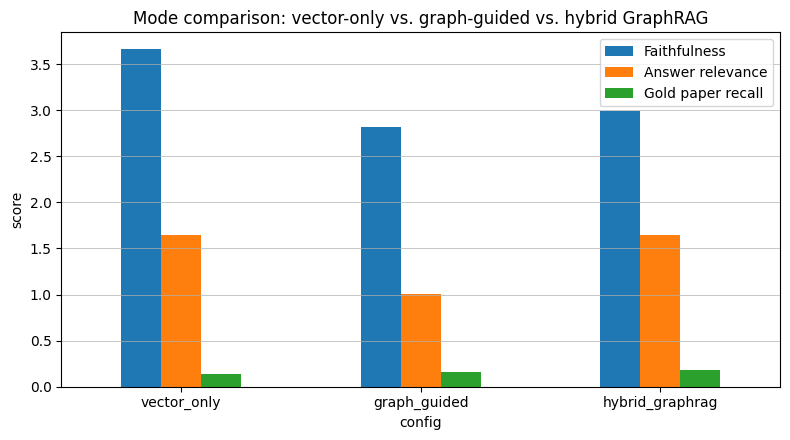

Saved plot -> C:\Users\97150\Documents\GitHub\CLPapersAIAgent\notebook_cache\06_eval_ablation\mode_comparison_bar.png


In [9]:
preset_rows = summary_df[summary_df["config"].isin(preset_order)].set_index("config").loc[preset_order]
metrics_to_plot = ["mean_faithfulness", "mean_answer_relevance", "mean_gold_recall"]

fig, ax = plt.subplots(figsize=(8, 4.5))
preset_rows[metrics_to_plot].plot(kind="bar", ax=ax)
ax.set_title("Mode comparison: vector-only vs. graph-guided vs. hybrid GraphRAG")
ax.set_ylabel("score")
ax.set_xticklabels(preset_rows.index, rotation=0)
ax.legend(["Faithfulness", "Answer relevance", "Gold paper recall"])
ax.grid(True, axis="y", linewidth=0.5)

plt.tight_layout()
mode_plot_path = EVAL_ABLATION_CACHE / "mode_comparison_bar.png"
plt.savefig(mode_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved plot ->", mode_plot_path)

## Final Interpretation

Across the three named presets, **vector_only** was the most faithful (mean faithfulness
3.664/5), followed by **hybrid_graphrag** (2.994) and **graph_guided** (2.822) -- faithfulness
drops as graph-expanded evidence carries more weight, since topic-shared papers support an
answer's literal claims less directly than the chunks retrieval actually pulled for that
question. Answer relevance shows the same ordering, more sharply: vector_only and
hybrid_graphrag are essentially tied (1.645 and 1.650), while graph_guided collapses to 1.0075
-- heavy graph weighting visibly pulls the answer off-topic.

Gold-paper precision and recall reveal a genuine trade-off rather than graph expansion being a
clean win or loss: vector_only has the highest precision (0.578) but the lowest recall (0.133)
-- when it cites a paper it's more likely to be gold-relevant, but it never looks beyond the
originally retrieved chunks' own papers, so it misses more of the broader relevant set. Enabling
graph expansion trades some of that precision away (down to 0.42-0.49 across every graph-enabled
config) for a modest recall gain (0.16-0.18) -- but `graph_guided`'s heavier weighting doesn't
buy more recall than `hybrid_graphrag`'s lighter weighting (0.161 vs. 0.180, actually lower), it
just costs more precision, faithfulness, and relevance for no extra benefit. Citation coverage is
1.0 everywhere by construction and isn't discriminating here.

The weight-grid sweep (evidence budget fixed at 8 throughout) shows faithfulness and gold
precision both peaking around `graph_weight=0.2-0.3` (faithfulness 3.103, precision 0.489 at
0.3) before dropping sharply at `graph_weight=0.4` (2.822, 0.418) -- the same point as the
`graph_guided` preset. Answer relevance, however, declines monotonically once `graph_weight`
passes 0.1 (1.650 -> 1.635 -> 1.340 -> 1.0075), so there's no single sweet spot: `0.3` is best
for faithfulness/precision, but `hybrid_graphrag`'s lighter `0.1` is still the better overall
choice once relevance is weighed in. Either way, `graph_guided`'s `0.4` is the worst point on
nearly every quality metric in the sweep, which is solid empirical support for `hybrid_graphrag`
being the safer default.

One subtlety worth flagging directly: `grid_r1.0_g0.0_q0.0` (graph expansion *on*, `graph_weight`
forced to 0) is **not** equivalent to `vector_only` (graph expansion structurally *off*), even
though both nominally carry the same retrieval weight -- 2.950 faithfulness vs. 3.664.
`rerank_evidence()` applies `retrieval_weight` to every candidate's own `retrieval_score`,
including graph-sourced chunks, so graph evidence can still win a slot in the final ranking
purely on its in-paper TF-IDF relevance even when `graph_weight=0` -- zeroing the graph weight
suppresses the *graph_score* channel, not graph evidence's presence in the candidate pool. Worth
a sentence in the report, and worth flagging to Member 1 if `graph_weight=0` was intended to
fully match `vector_only`'s behavior.

Latency is driven almost entirely by whether graph expansion runs at all, not by how heavily it's
weighted: vector_only averages 178ms (p95 230ms) versus roughly 250-275ms average (p95 290-350ms)
for every graph-enabled config, including the lightest-weighted ones -- the weight itself barely
moves latency once expansion is switched on, since expansion gets computed regardless of the
score it ends up receiving.

`ablation_results_long.csv` (per-question, per-config) and `ablation_summary.csv` (aggregated)
are the two files to hand to Member 4 for the final report.